Module importing

In [1]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset

sys.path.append('D:/ppg_project/code/model_build/my_tool/model')
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')

from multiResUnet_1D_demo import MultiResUnet
from model_builder import k_fold_training
from performance import performance
from ppg_labeled_load import PPGDataset

Data prepairing

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('can use cuda')
else:
    device = torch.device('cpu')
    print('using cpu')

can use cuda


254
torch.Size([1, 800])


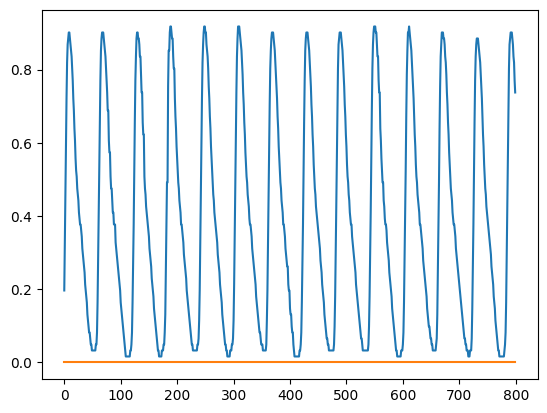

In [3]:
#Import_data
dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})
print(dataset.count)

print(dataset[111][0].shape)
for i in [22]:
    plt.plot(dataset[i][0].numpy().flatten())
    plt.plot(dataset[i][1].numpy().flatten())

# plt.plot(dataset[0][1].numpy())
    plt.show()

Training

In [4]:
import torch.nn.functional as F

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {
    "Number class": 1, # Regression output 1 channel
    "Serie length": 1024, 
    "Input size": 1,
    "Filter nums": [32, 64, 128, 256], # Tăng độ sâu model
    "Expand": [2, 2, 2, 2],
    "Respath kernel": 3,
    "Block kernel": [3, 5, 7],
    "Filter rate": [1.67, 0.333, 0.5],
    "Pooling kernel": [2, 2, 2, 2],
    "Transpose kernel": [2, 2, 2, 2],
    "Respath length": 4,
    "dropout_rate": 0.1 # Thêm dropout rate
}

def loss(predict, truth):
    truth = truth.to(torch.int64)  # Ensure labels are int64 for PyTorch compatibility
    log_prob = F.log_softmax(predict, dim=1)  # Compute log-softmax
    loss = -log_prob.gather(dim=1, index=truth.unsqueeze(1)).squeeze(1)  # Gather log probabilities of the correct classes
    return loss.mean()

model = MultiResUnet(para = para, alpha = 1.67).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)
builder = k_fold_training(dataset,5, criterion = nn.L1Loss())
builder.training(model,device,optimizer,num_epochs=200,batch=64,visualize=1)

d:\ppg_project\venvppg\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Fold : 1
Train and validate dataset are overlap:  False
Iteration: 1/200. loss_train: 0.531639814376831. loss_val: 0.20377039909362793
Iteration: 2/200. loss_train: 0.2824143171310425. loss_val: 0.1770523339509964
Iteration: 3/200. loss_train: 0.21360108256340027. loss_val: 0.4492664039134979
Iteration: 4/200. loss_train: 0.15691247582435608. loss_val: 0.112099289894104
Iteration: 5/200. loss_train: 0.1370396912097931. loss_val: 0.07639111578464508
Iteration: 6/200. loss_train: 0.11509620398283005. loss_val: 0.07086291909217834
Iteration: 7/200. loss_train: 0.10049653053283691. loss_val: 0.07053253054618835
Iteration: 8/200. loss_train: 0.10226847976446152. loss_val: 0.11764434725046158
Iteration: 9/200. loss_train: 0.08706628531217575. loss_val: 0.06744147092103958
Iteration: 10/200. loss_train: 0.08404533565044403. loss_val: 0.06398960202932358
Iteration: 11/200. loss_train: 0.09355324506759644. loss_val: 0.06414421647787094
Iteration: 12/200. loss_train: 0.08175132423639297. loss_va

Performance

Max loss:  0.99891096
Mean loss:  0.28002846
Min loss:  0.0010448673
Number of test:  84


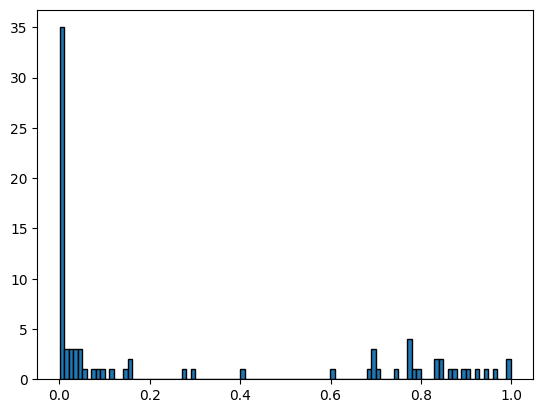

0.15717117


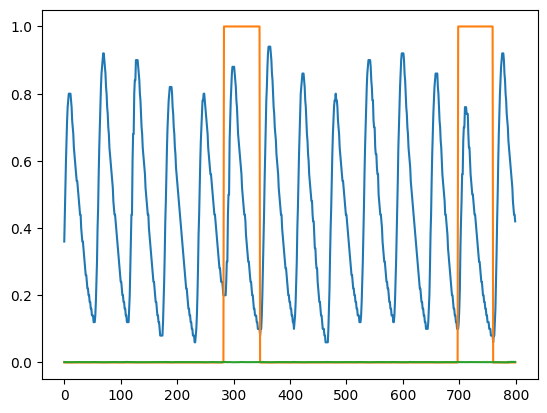

0.7814621


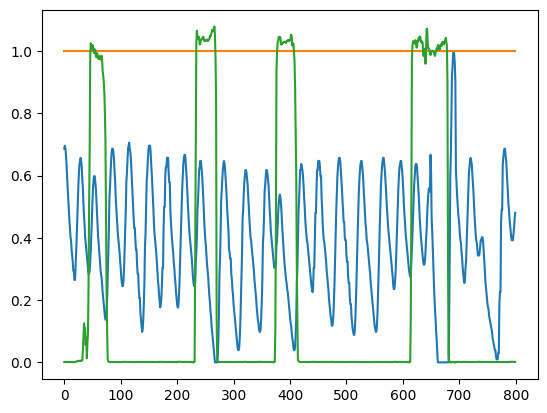

0.8521148


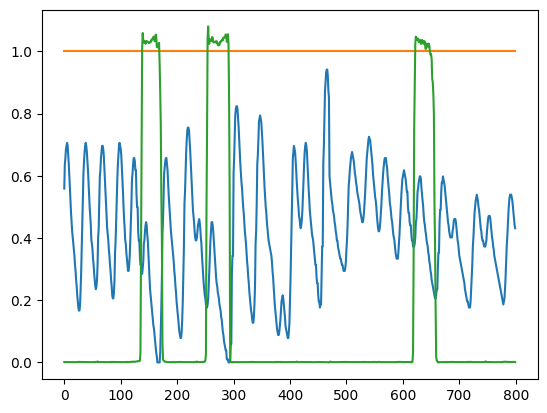

1.2310587e-06


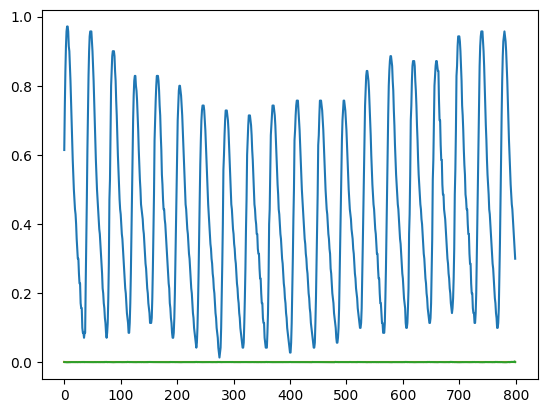

1.3212385e-06


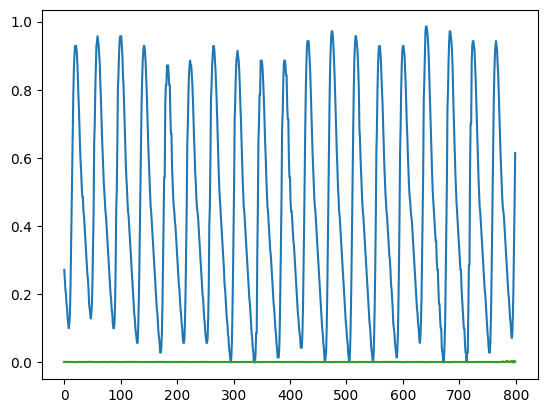

1.1699344e-06


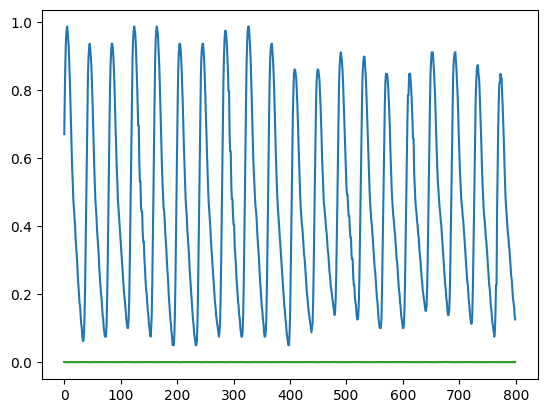

1.1540867e-06


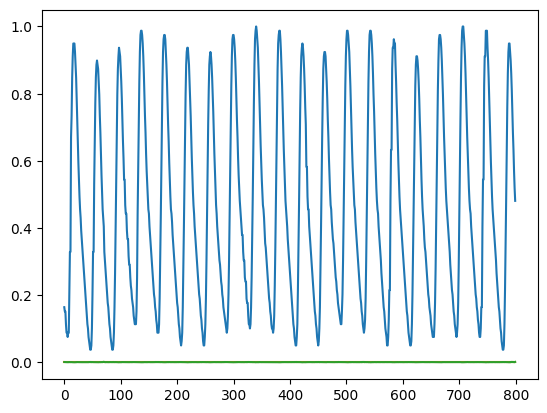

0.8736056


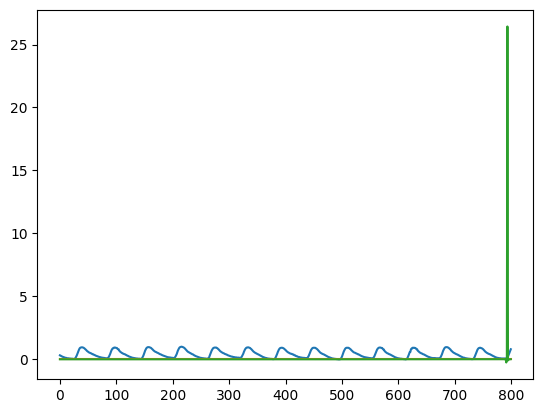

1.1930443e-06


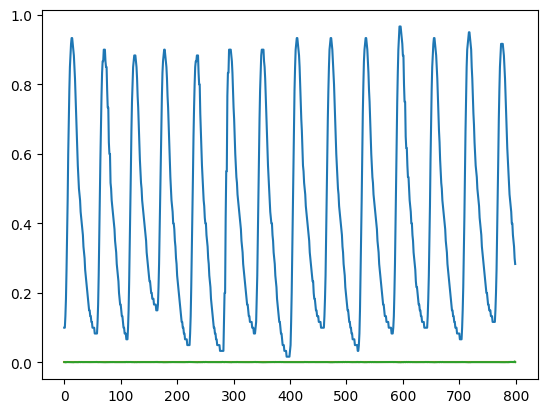

1.1958062e-06


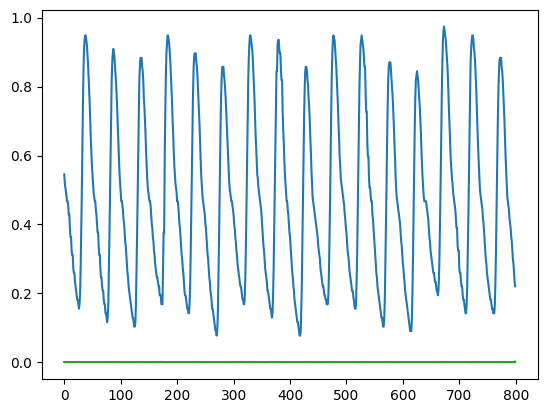

1.1797802e-06


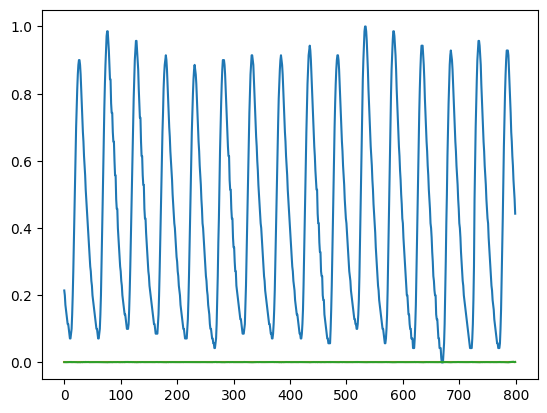

1.1973816e-06


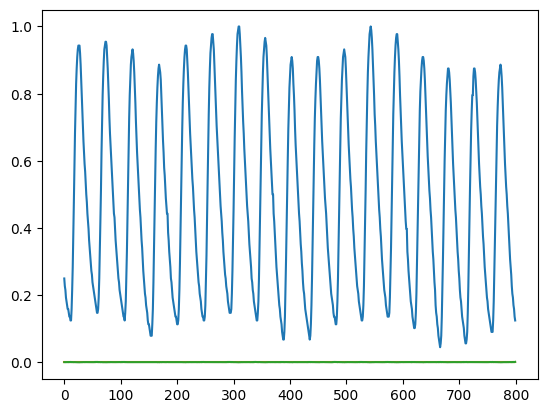

0.0037752162


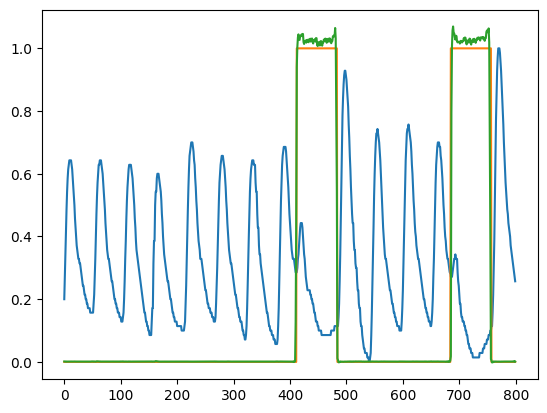

0.088687286


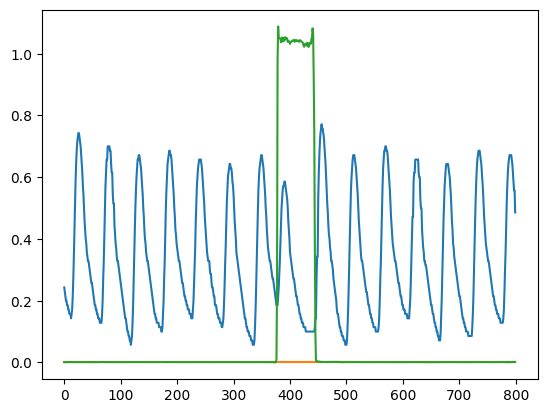

0.009316047


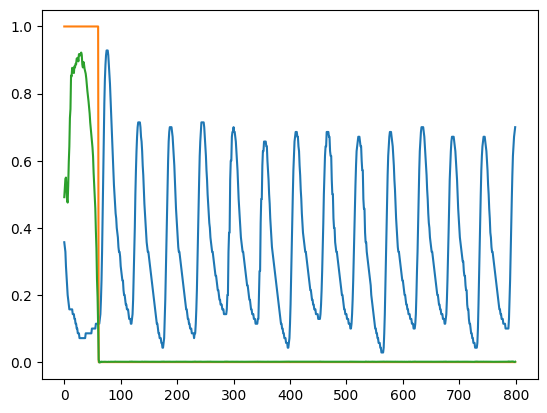

1.2645102e-06


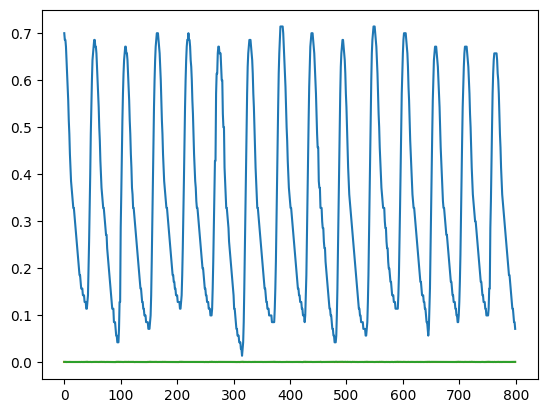

0.86549985


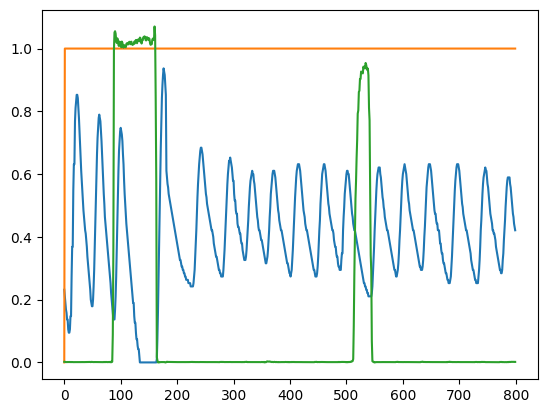

0.9554791


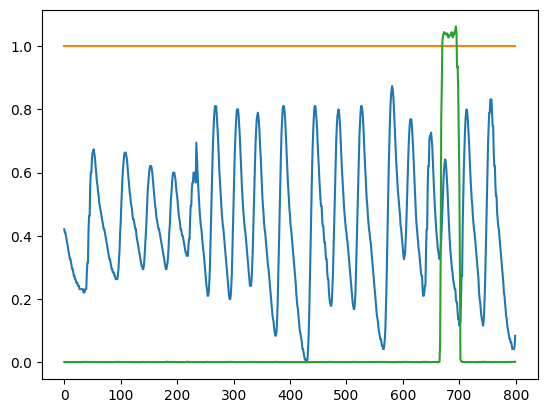

0.75316143


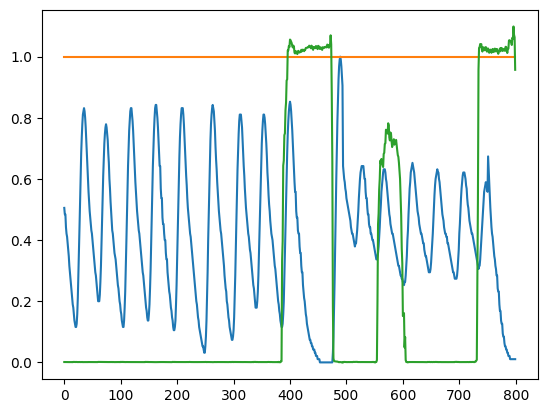

0.66990316


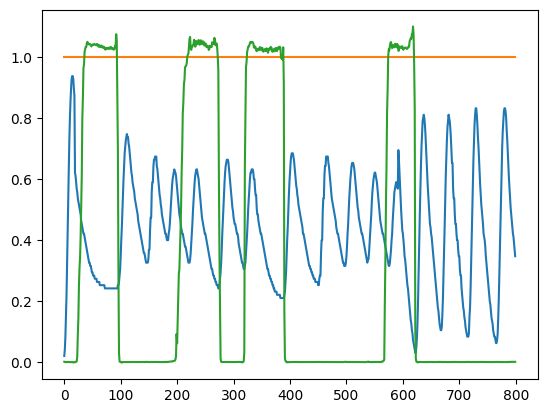

0.83290875


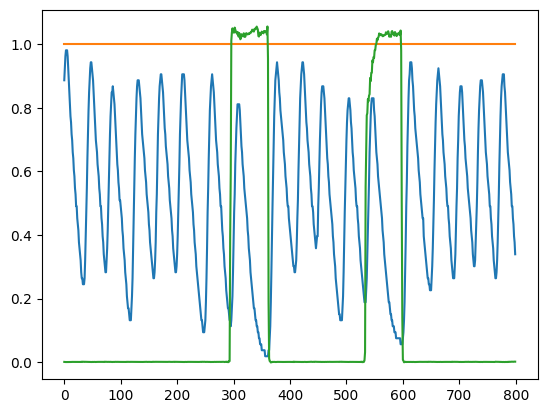

1.1210298e-06


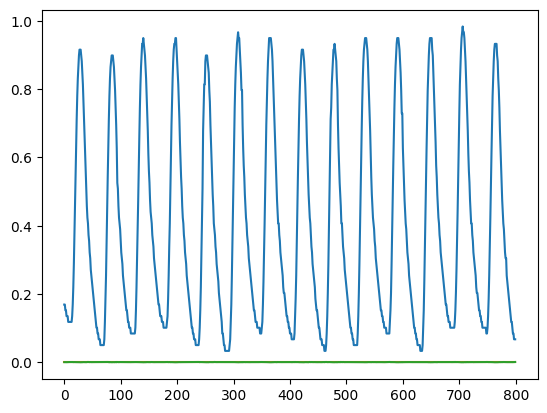

1.1358981e-06


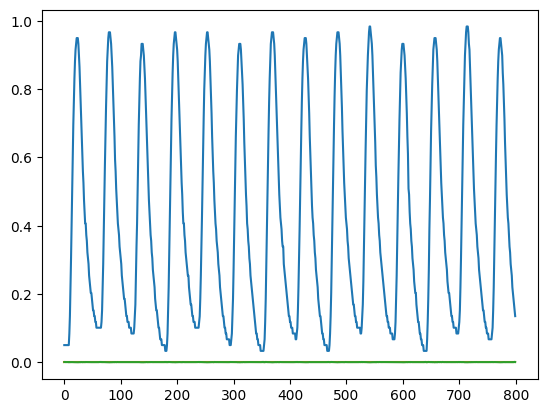

1.174536e-06


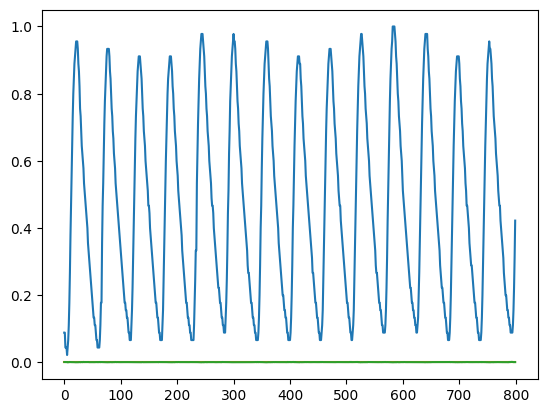

1.21198e-06


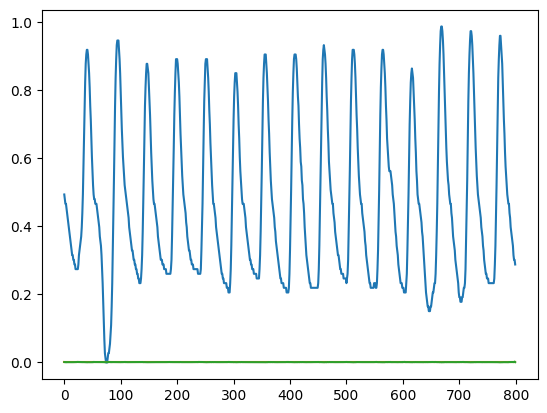

0.8364818


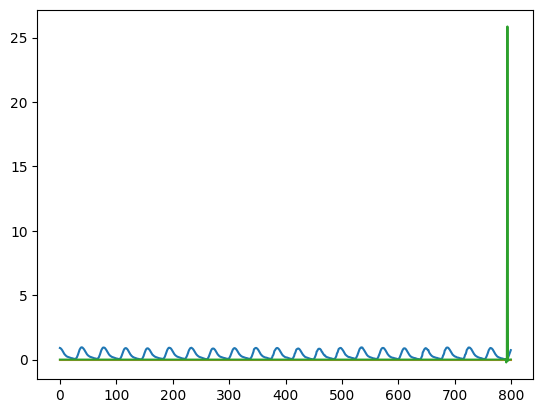

0.9392252


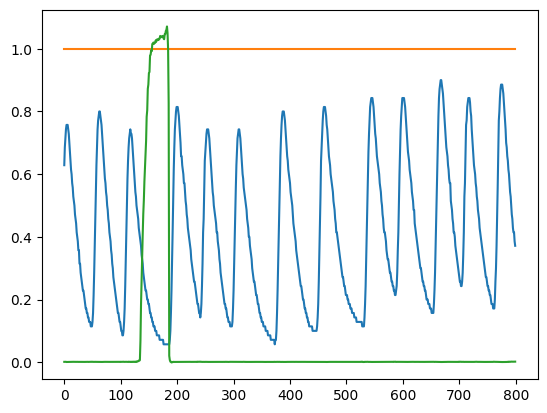

1.2004826e-06


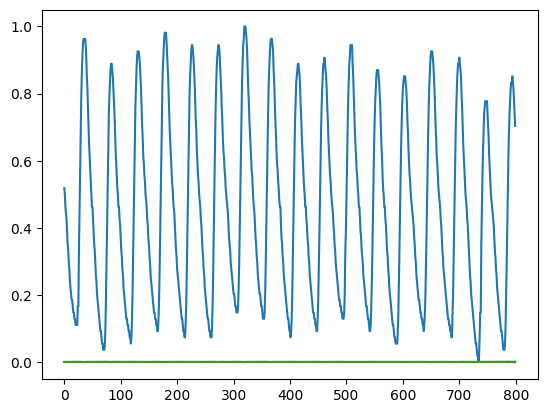

1.2064677e-06


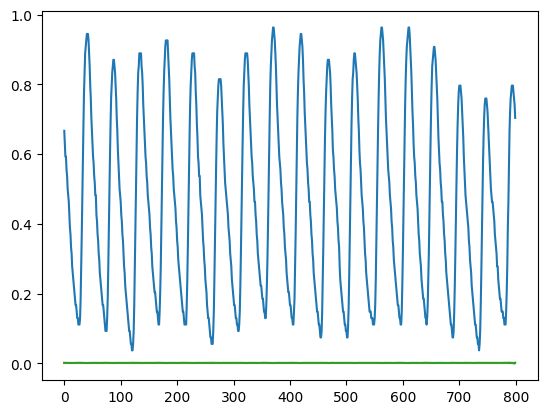

0.68057996


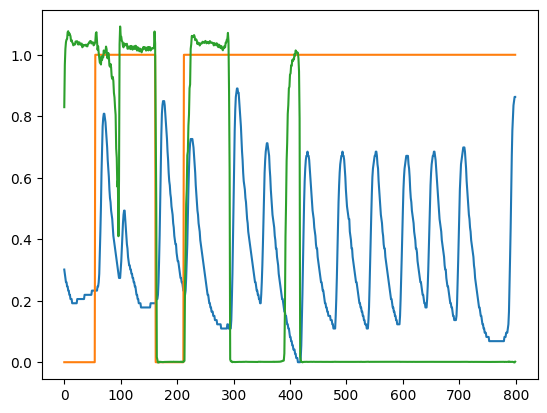

1.1800253e-06


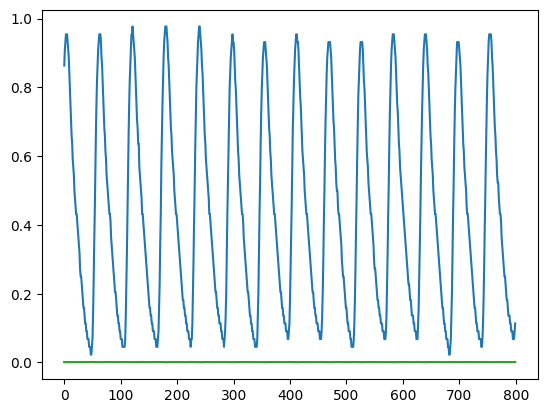

1.4347775e-06


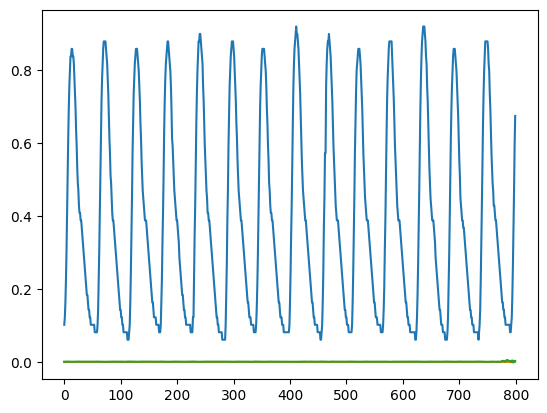

1.2011687e-06


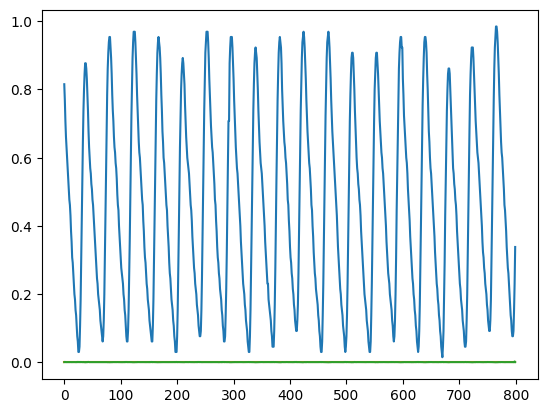

1.2108044e-06


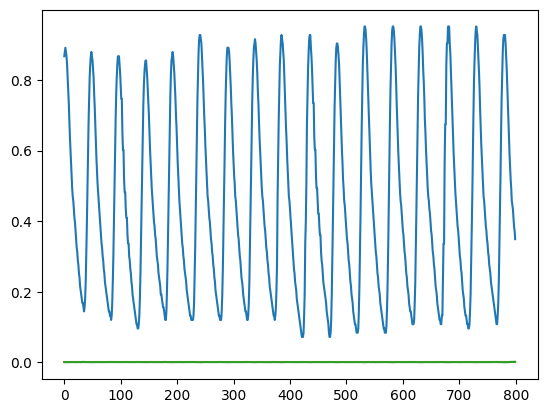

1.1778312e-06


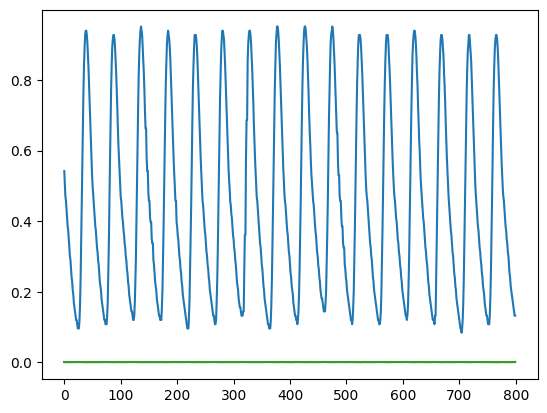

1.3824504e-06


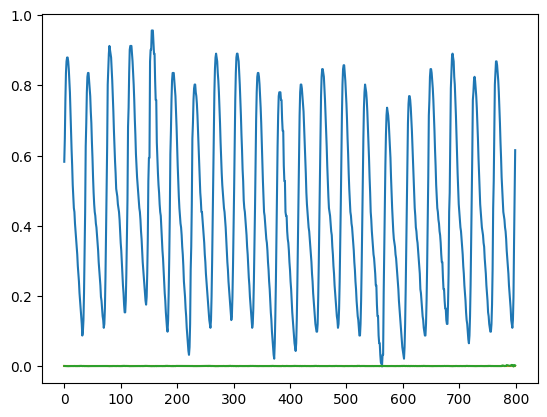

1.2824603e-06


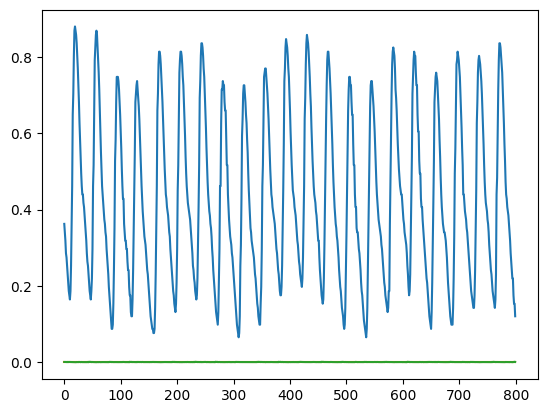

1.259234e-06


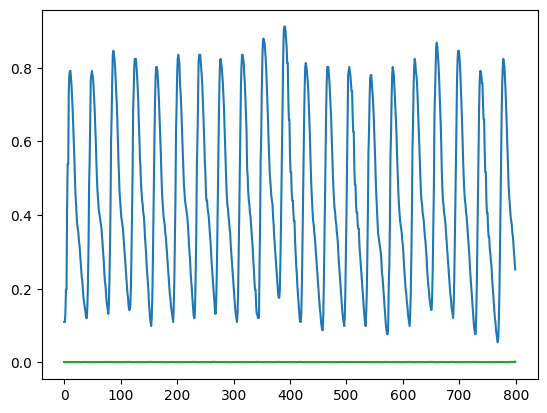

1.2783438e-06


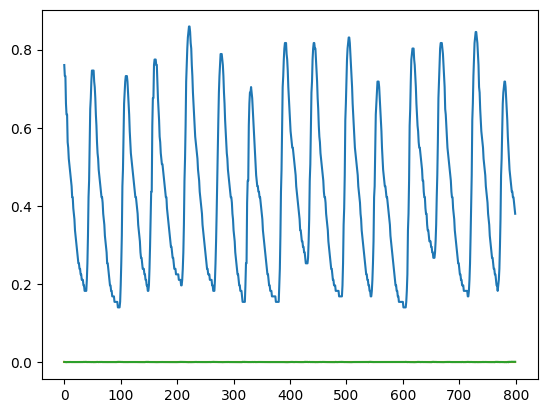

0.7583467


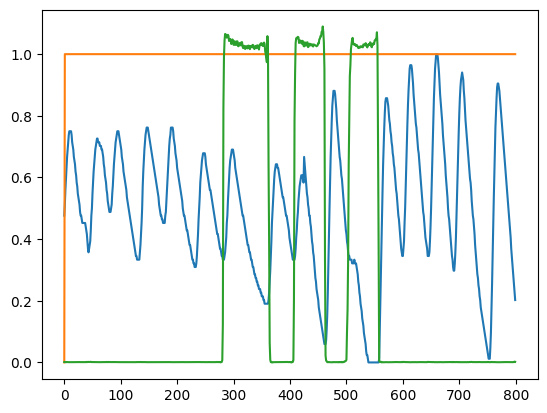

1.245744e-06


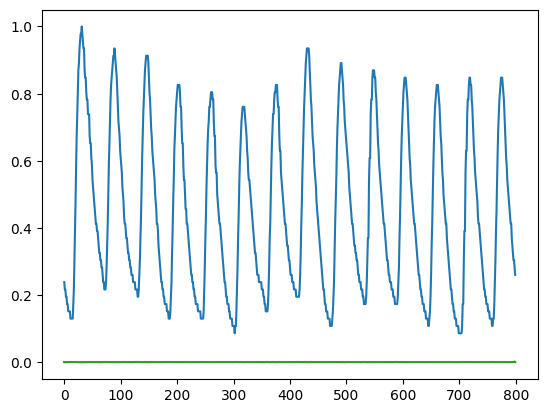

0.8018718


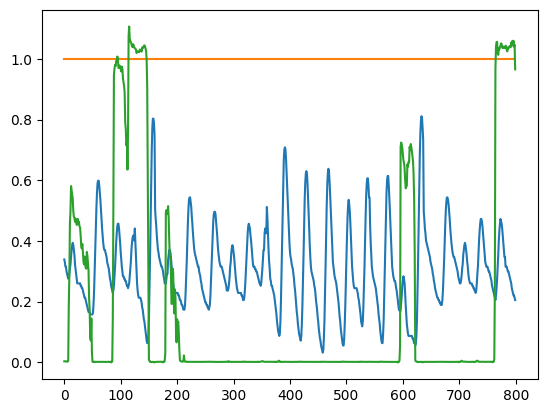

0.8302948


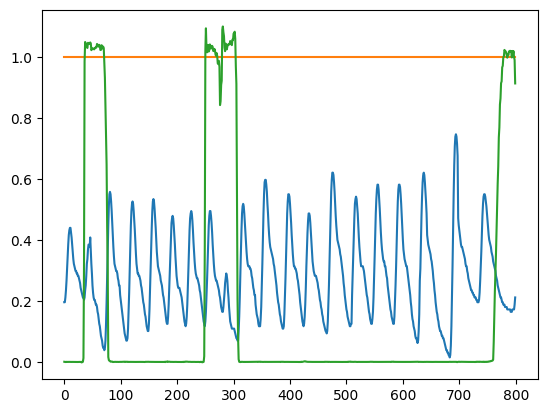

1.3392226e-06


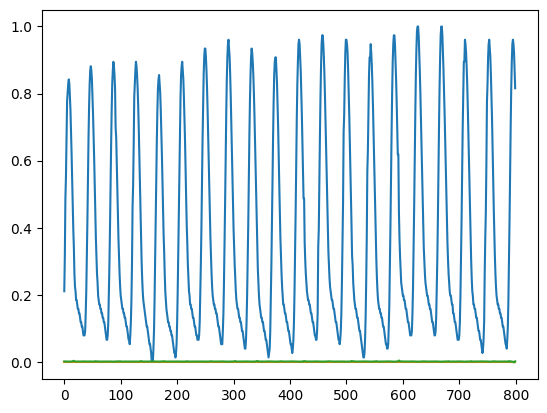

0.002856806


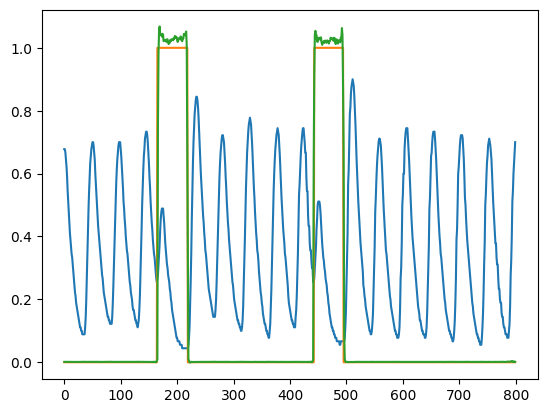

0.04830326


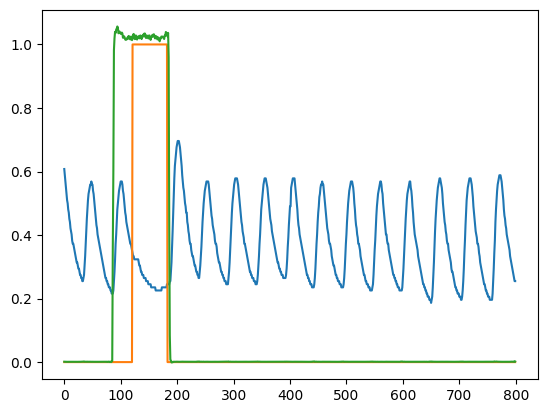

0.0018800461


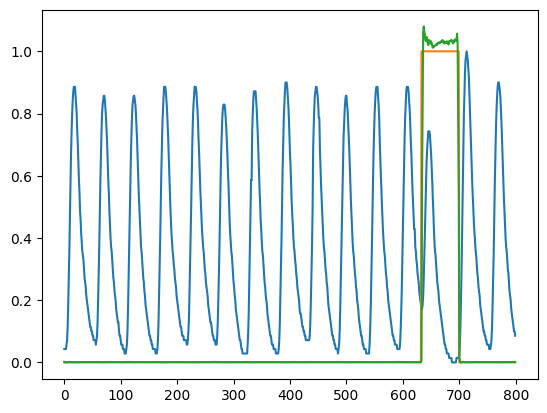

0.68456894


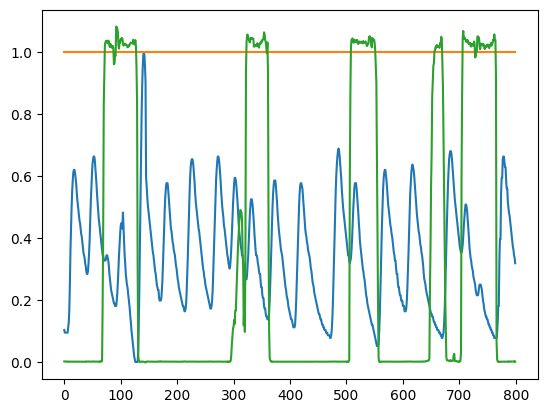

0.758867


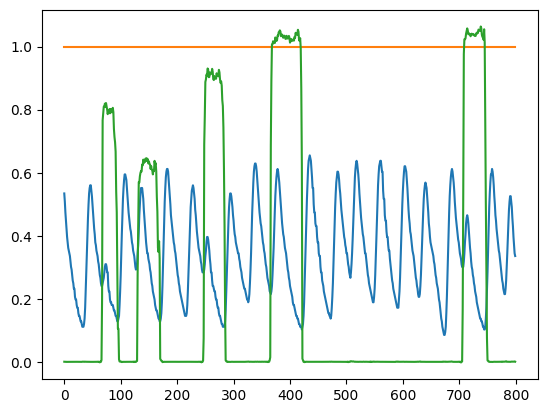

0.02031626


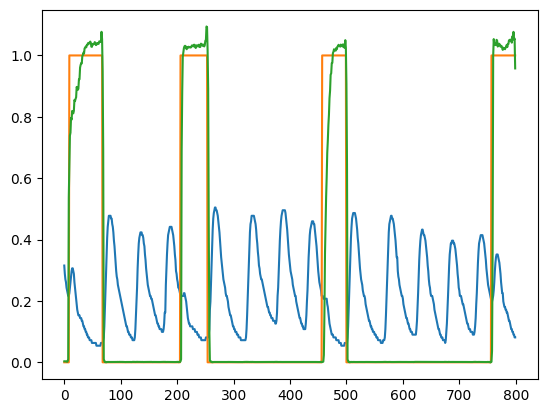

0.032644182


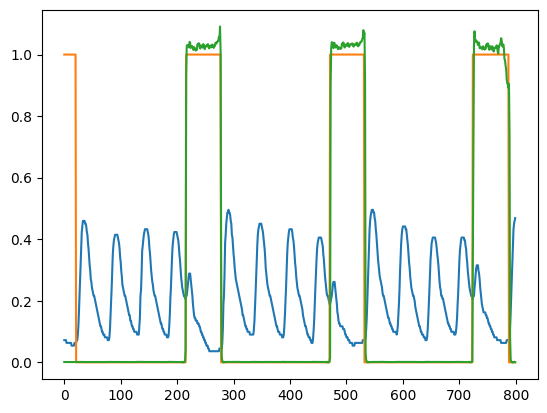

0.09505467


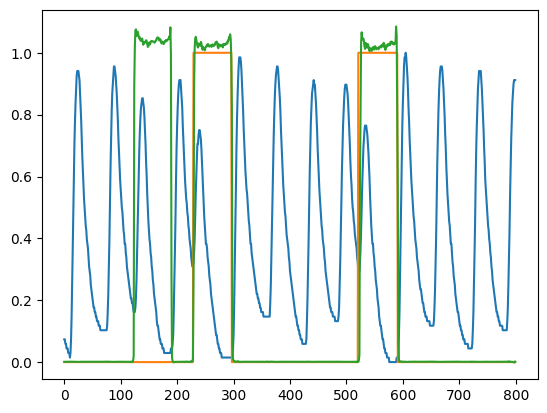

1.1314194e-06


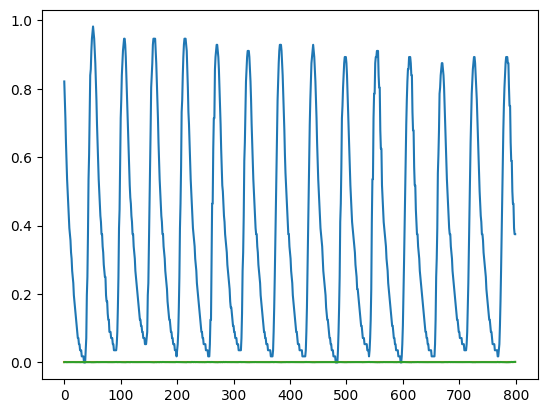

2.3616974e-06


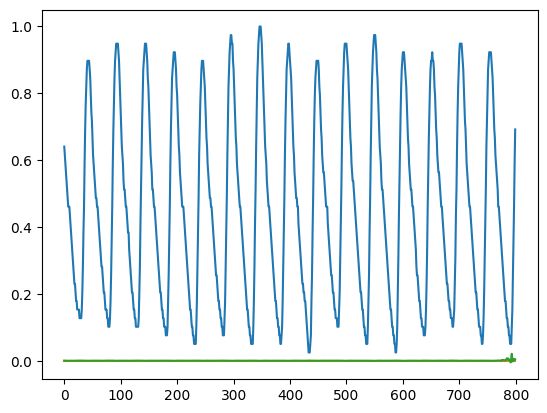

1.1872756e-06


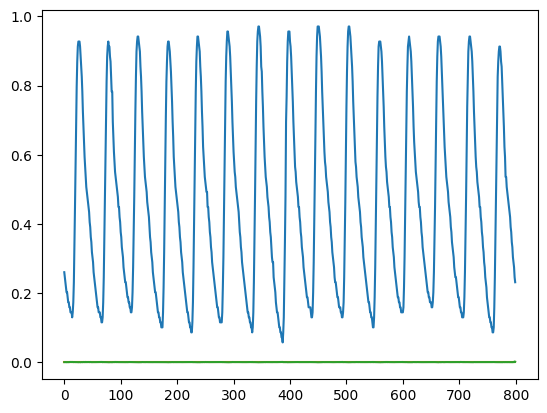

0.6647732


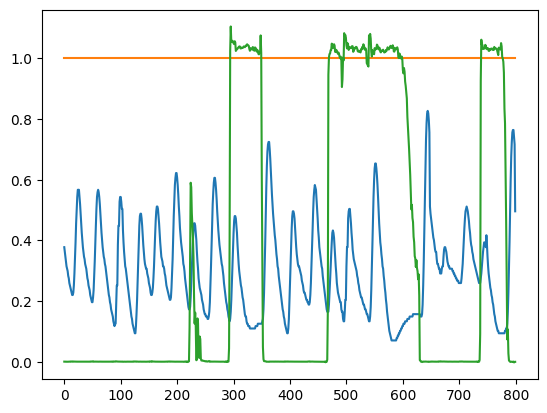

0.5776147


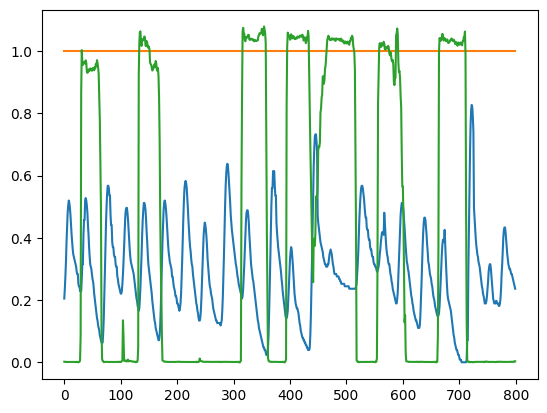

0.0015032557


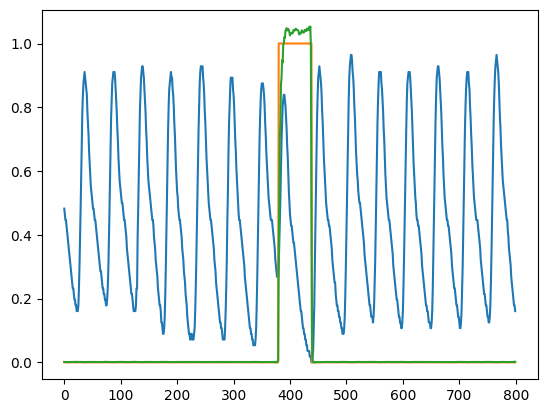

0.9011291


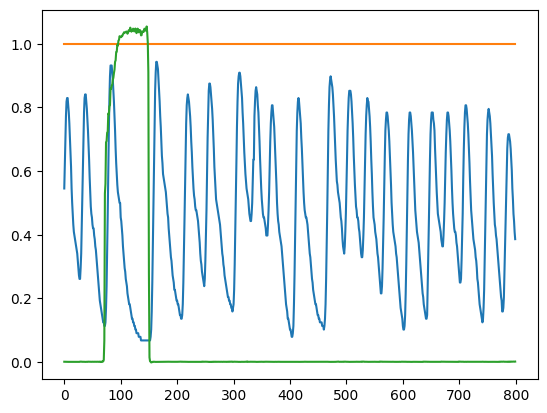

0.76292455


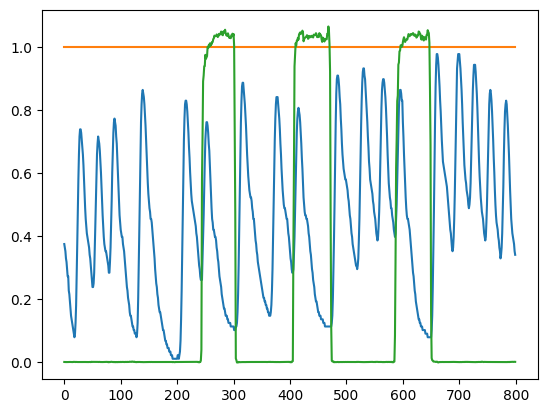

0.91628087


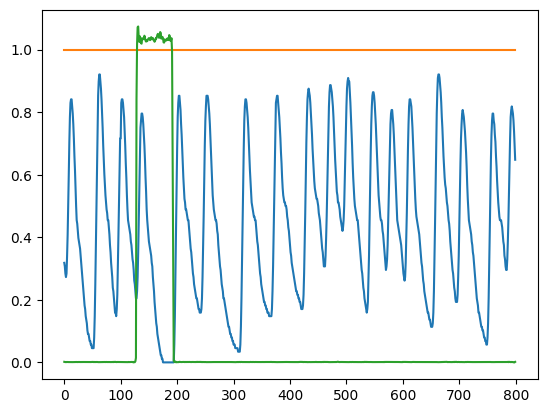

0.032362357


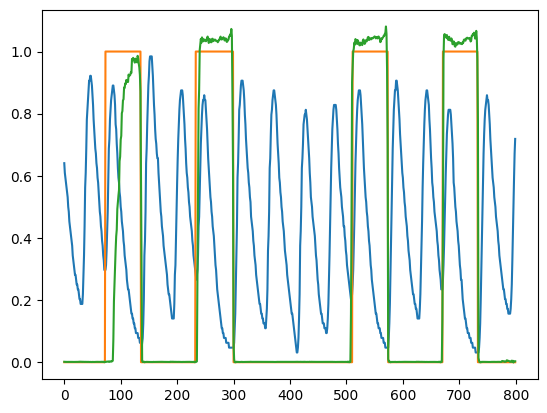

0.394335


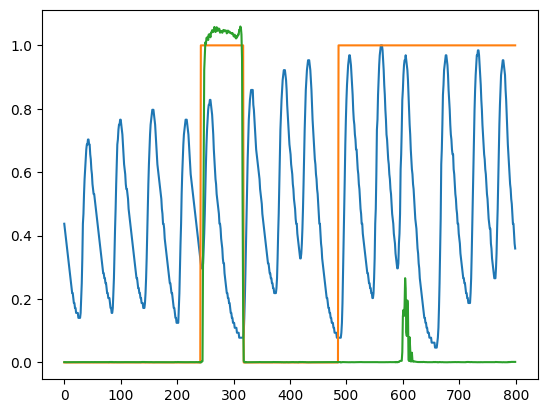

0.01884787


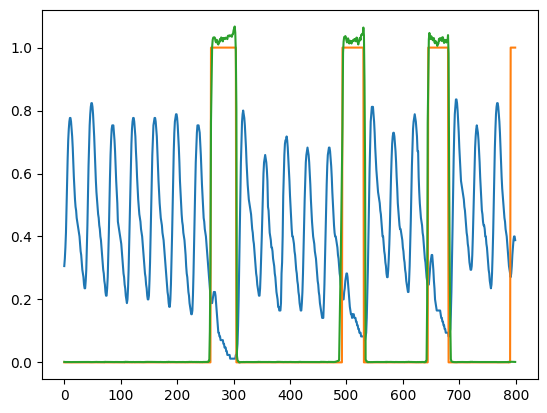

0.13905746


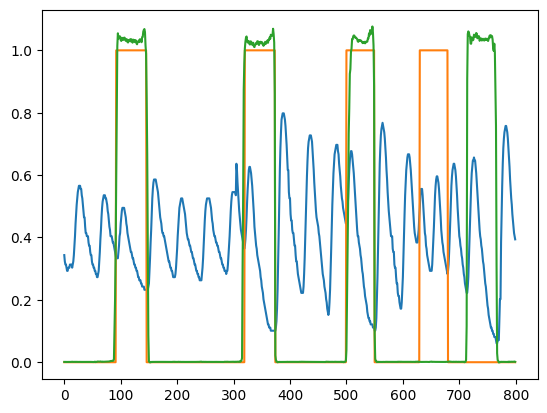

1.228945e-06


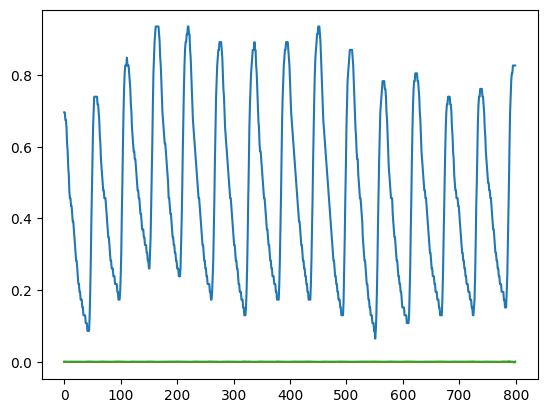

0.76116055


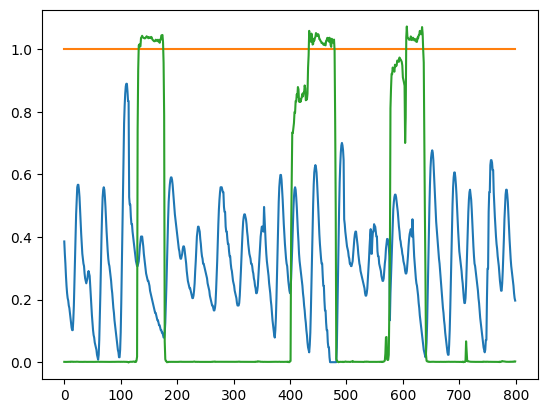

0.06347545


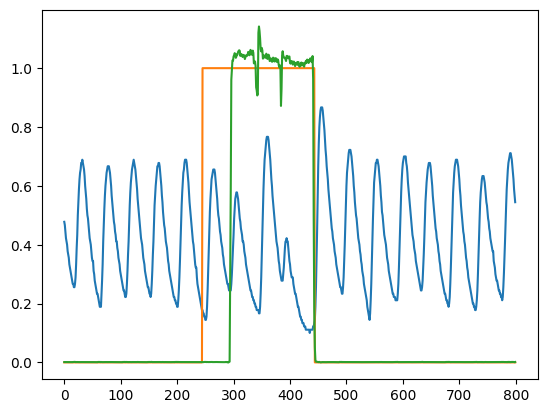

0.28673923


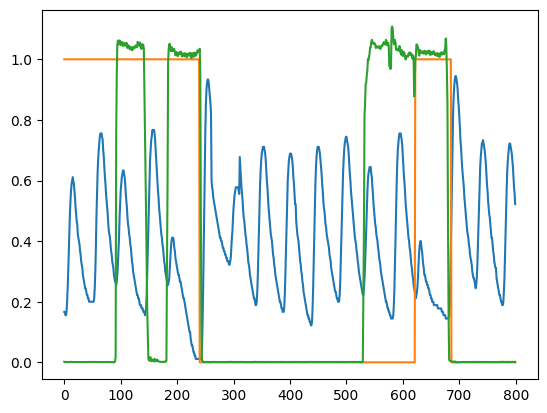

0.007853535


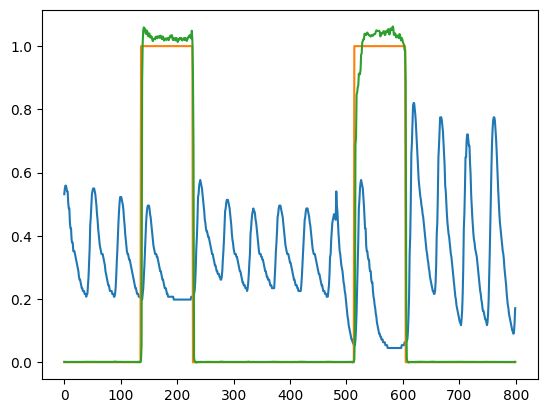

0.0052788765


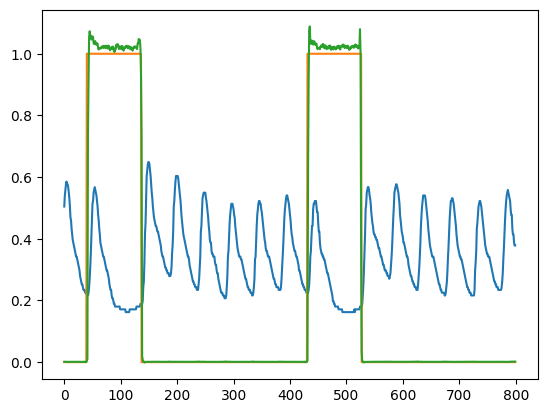

0.0020000744


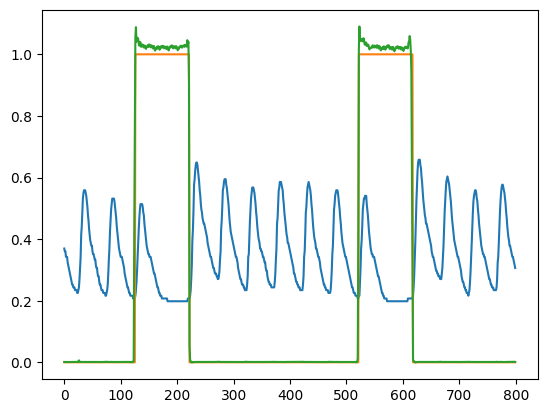

0.0020326178


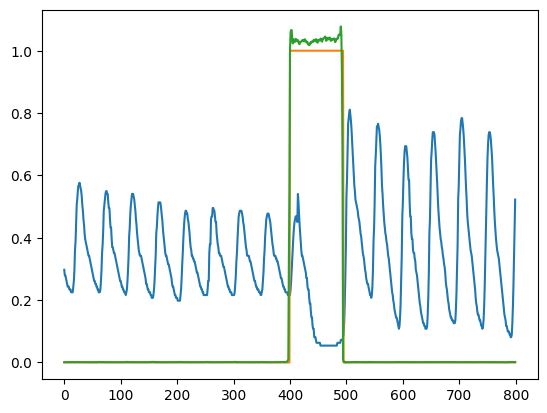

0.11841826


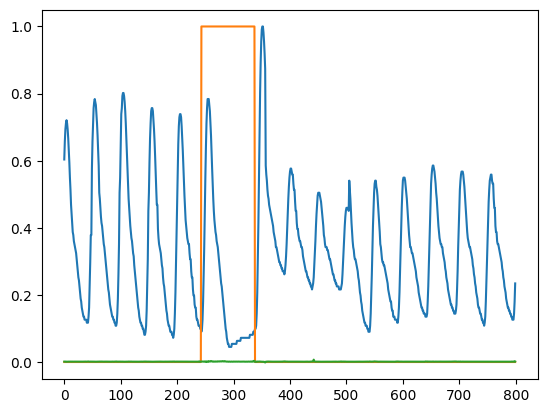

0.6606069


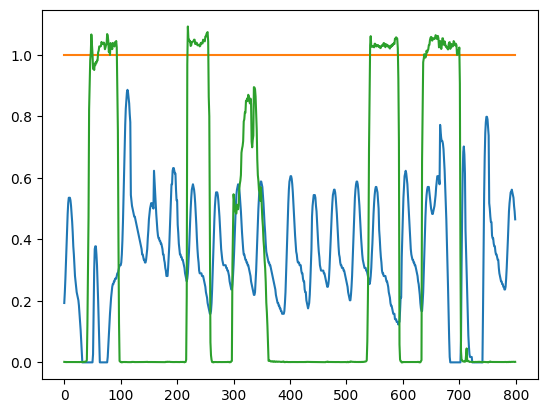

0.7327386


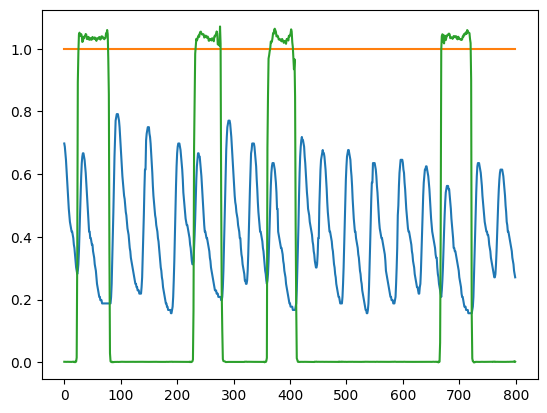

0.9975607


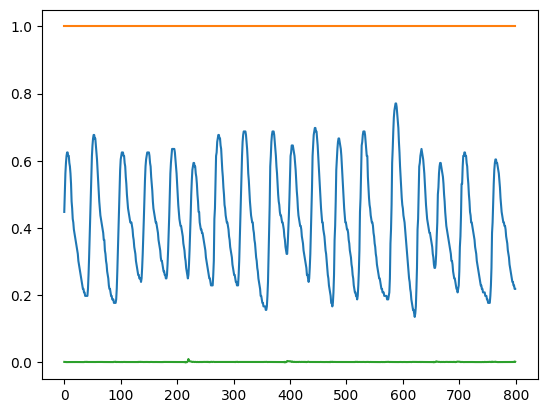

0.997823


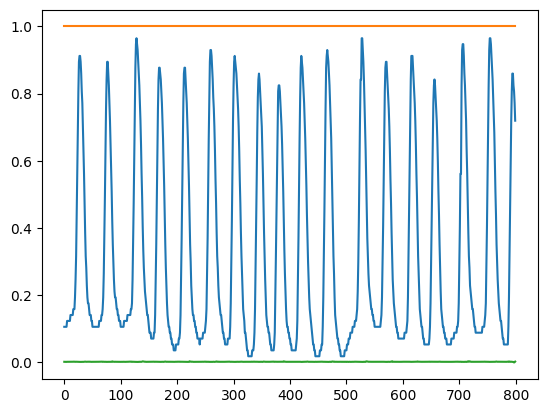

0.26138002


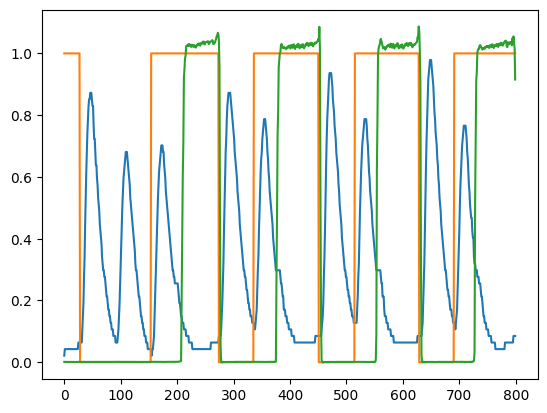

0.158215


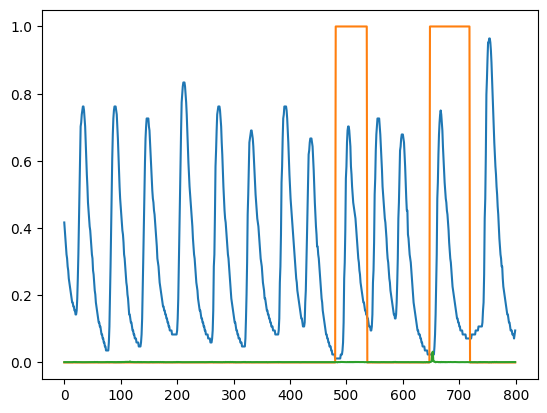

0.82108825


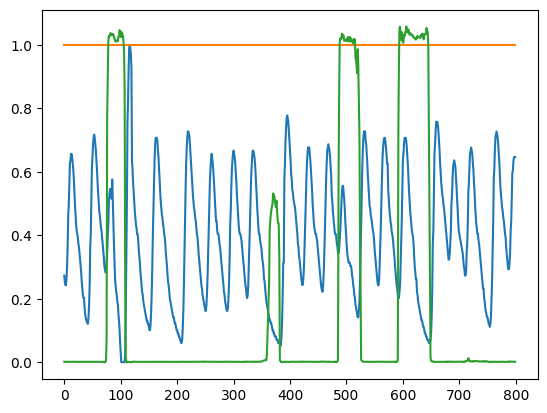

0.87525094


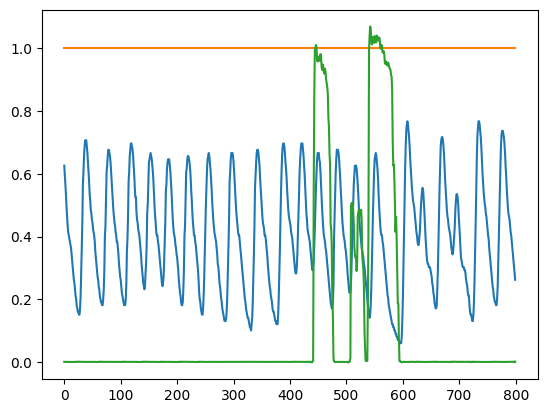

0.040380612


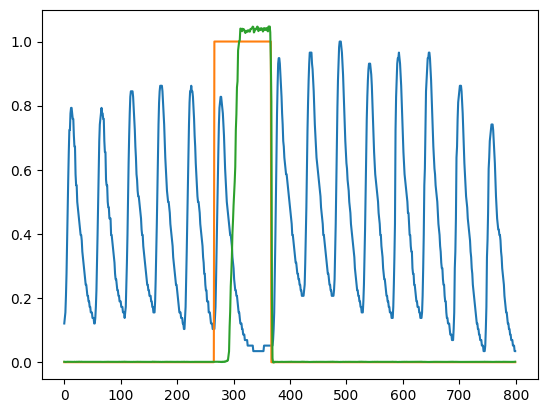

0.0186044


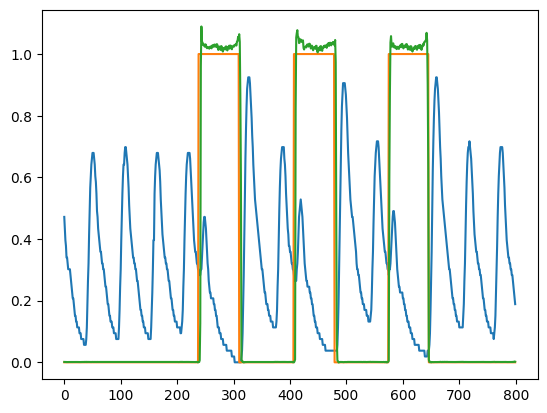

In [5]:
shower = performance()
test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")
shower.test(model,device,test_data,per_fnc = "series")
criterion = nn.MSELoss()
for i in range(len(test_data)):
    output = torch.stack([test_data[i][1]]).to(device)
    input = torch.stack([test_data[i][0]]).to(device)
    y_hat = model.forward(input)
    loss = criterion(y_hat,output)
    # if loss.cpu().detach().numpy()<0.3:
    print(loss.cpu().detach().numpy())
    plt.plot(input.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(output.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(y_hat.cpu().detach().numpy().flatten()[0:1000])
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error
from ppg_labeled_load import PPGDataset # Import dataset

# --- 1. LOAD TEST DATA (Tránh lỗi NameError) ---
# Đảm bảo đường dẫn đúng
try:
    test_data = PPGDataset(r'D:\ppg_project\Data\data_test', label_list="AR")
    print(f"Loaded Test Data: {len(test_data)} samples")
except Exception as e:
    print(f"Error loading data: {e}")
    # Tạo dummy data nếu lỗi để code không crash
    test_data = [] 

# --- SNR CALCULATION FUNCTION ---
def calculate_snr(y_true, y_pred):
    noise = y_true - y_pred
    signal_power = np.sum(y_true ** 2)
    noise_power = np.sum(noise ** 2)
    if noise_power == 0:
        return 100.0
    return 10 * np.log10(signal_power / noise_power)

# --- CONFIGURATION ---
num_samples = 100
cols = 2
rows = 50 
limit_points = 1000 

# Lists to store statistical results
stats_data = []

# Create a large figure
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows)) 
fig.suptitle(f"Comparison and Statistics of {num_samples} Samples", fontsize=16, y=1.002)
axes = axes.flatten()

criterion = nn.L1Loss()
model.eval()

print(f"Processing and plotting {num_samples} samples...")

with torch.no_grad():
    for i in range(num_samples):
        ax = axes[i]
        
        if i < len(test_data):
            # 1. Get Data & Forward Pass
            output = torch.stack([test_data[i][1]]).to(device)
            input_sig = torch.stack([test_data[i][0]]).to(device)
            
            y_hat = model(input_sig)
            
            # 2. Calculate Loss
            loss_val = criterion(y_hat, output).item()
            
            # 3. Convert to Numpy & Flatten
            np_in = input_sig.cpu().detach().numpy().flatten()[:limit_points]
            np_out = output.cpu().detach().numpy().flatten()[:limit_points]
            np_pred = y_hat.cpu().detach().numpy().flatten()[:limit_points]
            
            # 4. Calculate Statistics
            mae = mean_absolute_error(np_out, np_pred)
            rmse = np.sqrt(mean_squared_error(np_out, np_pred))
            pearson, _ = pearsonr(np_out, np_pred)
            snr = calculate_snr(np_out, np_pred)
            
            stats_data.append({
                "Sample": i, "MAE": mae, "RMSE": rmse, "Pearson": pearson, "SNR (dB)": snr
            })
            
            # 5. PLOTTING
            # Input (Noisy) -> BLUE (Xanh dương)
            ax.plot(np_in, label='Input', color='blue', alpha=0.4, linewidth=1)
            
            # Output (Ground Truth) -> ORANGE
            ax.plot(np_out, label='Output', color='orange', alpha=0.8, linewidth=1.5)
            
            # Prediction (y_hat) -> GREEN (Solid line)
            ax.plot(np_pred, label='Prediction', color='green', linestyle='-', linewidth=1.5)
            
            ax.set_title(f"Sample {i} | L1 Loss: {loss_val:.4f} | Pearson: {pearson:.4f}", fontsize=9)
            
            if i == 0: ax.legend(loc='upper right') 
            
        else:
            ax.axis('off')

plt.tight_layout()
plt.show()

model.train() 

# --- DISPLAY STATISTICS ---
print("\n" + "="*30 + " STATISTICAL RESULTS TABLE " + "="*30)
df_stats = pd.DataFrame(stats_data)
mean_metrics = df_stats[["MAE", "RMSE", "Pearson", "SNR (dB)"]].mean()
df_stats.loc['AVERAGE'] = mean_metrics
df_stats.loc['AVERAGE', 'Sample'] = '---' 

try:
    from IPython.display import display
    display(df_stats)
except:
    print(df_stats)

print("\n" + "-"*20 + " SUMMARY " + "-"*20)
print(f"Average MAE:     {mean_metrics['MAE']:.5f}")
print(f"Average RMSE:    {mean_metrics['RMSE']:.5f}")
print(f"Average Pearson: {mean_metrics['Pearson']:.5f}")
print(f"Average SNR:     {mean_metrics['SNR (dB)']:.2f} dB")